# **MÓDULO 18 - Pratique**
# Regressão Linear

Agora que aprendemos como aplicar a regressão linear simples e múltipla, colocaremos em prática os conceitos vistos na aula.

Temos aqui uma base de imóveis para alugar, precisamos desenvolver um modelo de regressão linear múltipla para conseguir prever o preço de imóveis dadas as variáveis independentes do nosso modelo.

**Atenção! Esse é seu primeiro modelo, caso tenha dificuldade conte com a ajuda da tutoria**

Você notará que alguns códigos já estão presentes para facilitar a construção de vocês.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("ALUGUEL_MOD12.csv", delimiter=';')

df.head(10)

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0
5,500,380,66,2,1,0,1
6,550,100,48,2,2,1,1
7,600,110,46,2,2,1,1
8,600,100,49,2,2,1,1
9,600,325,50,2,2,1,1


Legenda dos dados:

*   **Valor_Aluguel** : valor Total pago no aluguel

*   **Valor_Condominio** : Valor do Condomínio.

*   **Metragem** : Metragem do Apartamento.

*   **N_Quartos** : Número de Quartos do Imóvel.

*   **N_banheiros** : Número de banheiros.

*   **N_Suites** : Número de Suítes.

*   **N_Vagas** : Número de Vagas.

# 1 - Realize a primeira etapa de pré processamento dos dados.

A) Verifique os tipos de dados.


B) Verifique os dados faltantes, se houver dados faltantes faça a substituição ou remoção justificando sua escolha.

In [3]:
# Verificando os tipos de dados
df.dtypes

Valor_Aluguel       int64
Valor_Condominio    int64
Metragem            int64
N_Quartos           int64
N_banheiros         int64
N_Suites            int64
N_Vagas             int64
dtype: object

In [4]:
# Verificando se há valores ausentes
df.isnull().sum()

Valor_Aluguel       0
Valor_Condominio    0
Metragem            0
N_Quartos           0
N_banheiros         0
N_Suites            0
N_Vagas             0
dtype: int64

In [5]:
# Verificando informações gerais do Dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7203 entries, 0 to 7202
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Valor_Aluguel     7203 non-null   int64
 1   Valor_Condominio  7203 non-null   int64
 2   Metragem          7203 non-null   int64
 3   N_Quartos         7203 non-null   int64
 4   N_banheiros       7203 non-null   int64
 5   N_Suites          7203 non-null   int64
 6   N_Vagas           7203 non-null   int64
dtypes: int64(7)
memory usage: 394.0 KB


**Ações e Justificativas**

Avaliado o Dataframe, verificamos que o conjunto de dados totaliza 7202 linhas sem dados faltantes. Não serão necessárias inclusões de dados.

Com relação as tipos de dados, serão convertidos para float os dados das tabelas a seguir:
- `Valor_Aluguel`
- `Valor_Condominio`
- `Metragem`

Apesar de não apresentarem valores com ponto flutuante, será corrigido para manter um padrão de dados adequado a cada variável.


In [6]:
# converendo as colunas 'Valor_Aluguel' e 'Valor_Condominio' e 'Metragem' para tipo float

df[['Valor_Aluguel', 'Valor_Condominio', 'Metragem']] = df[['Valor_Aluguel', 'Valor_Condominio', 'Metragem']].astype(float)

# verificando novamente os tipos de dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7203 entries, 0 to 7202
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Valor_Aluguel     7203 non-null   float64
 1   Valor_Condominio  7203 non-null   float64
 2   Metragem          7203 non-null   float64
 3   N_Quartos         7203 non-null   int64  
 4   N_banheiros       7203 non-null   int64  
 5   N_Suites          7203 non-null   int64  
 6   N_Vagas           7203 non-null   int64  
dtypes: float64(3), int64(4)
memory usage: 394.0 KB


# 2 - Realize a segunda etapa de pré processamento dos dados.

A) Utilize a função describe para identificarmos outliers e verificarmos a distribuição dos dados.


B) Caso note uma variável que te pareça conter outliers realiza a análise e tratamento desses dados, justificando a escolha do método utilizado.

C) Realize a análise bivariada dos dados. Faça uso de pelo menos 3 gráficos e traga insights acerca do analisado.

In [7]:
# Verificando a descrição do DataFrame
df.describe()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
count,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.00000
mean,2966.596140,811.538109,88.506178,2.300153,2.095932,1.016660,1.44176
std,2948.720385,796.564846,61.567505,0.826615,0.983812,0.874204,0.86993
min,480.000000,0.000000,30.000000,1.000000,1.000000,0.000000,0.00000
25%,1350.000000,395.000000,52.000000,2.000000,2.000000,1.000000,1.00000
50%,2000.000000,592.000000,67.000000,2.000000,2.000000,1.000000,1.00000
75%,3200.000000,980.000000,100.000000,3.000000,2.000000,1.000000,2.00000
max,25000.000000,9500.000000,880.000000,10.000000,8.000000,5.000000,9.00000


**Ações e Justificativas**

Realizando apenas a análise pelo método describe(), podemos verificar que as variáveis ‘Valor_Aluguel’, ‘Valor_condominio’ e ‘Metragem’ apresentam um desvio padrão alto, dando maior ênfase no valor de aluguel e condomínio que apresentam os maiores valores de desvio padrão. Isso pode ser indício de outliers.

Inúmeros fatores podem ser aplicados em função dessas variações como, localização do imovel, condomínio associado ao imovel, tamanho, com isso realizado a distorção natural do alguma variável.

Será realizado a investigação das três colunas acima e, caso necessário, será tratado


In [8]:
# Criando função para plotar gráficos boxplot das variáveis numéricas

def plot_boxplot(df, column):
    """
    Plota boxplots para as colunas especificadas em um DataFrame.

    Args:
        df (pd.DataFrame): DataFrame contendo os dados.
        columns_name (list): Lista de nomes das colunas a serem plotadas.

    Returns:
        None
    """
    # montando o gráfico com plotly
    fig = px.box(df, y=column)
    fig.update_layout(
        title=f'Boxplot de {column}',
        yaxis_title='Valores',
        xaxis_title=column,
        showlegend=False
    )
    # Exibindo o gráfico
    fig.show()

In [9]:
# graficando boxplot para a coluna 'Valor_Aluguel', 'Valor_Condominio' e 'Metragem'

plot_boxplot(df, 'Valor_Aluguel')
plot_boxplot(df, 'Valor_Condominio')
plot_boxplot(df, 'Metragem')

**Analisando dados do Valor_Aluguel**

In [10]:
# Valores acima do valor upper fence Valor_Aluguel
df[df['Valor_Aluguel']> 5900]

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
6454,5990.0,1188.0,164.0,3,5,3,3
6455,5999.0,1400.0,175.0,4,4,1,2
6456,6000.0,800.0,150.0,3,4,3,2
6457,6000.0,0.0,152.0,2,2,1,1
6458,6000.0,1100.0,43.0,1,2,1,1
...,...,...,...,...,...,...,...
7198,25000.0,7500.0,627.0,4,5,4,6
7199,25000.0,4600.0,364.0,4,2,1,0
7200,25000.0,3700.0,266.0,3,4,3,7
7201,25000.0,6000.0,600.0,4,5,4,8


In [11]:
# Verificando a porcentagem de valores acima do upper fence
porcentagem_acima_upper_fence = (df[df['Valor_Aluguel'] > 5900].shape[0] / df.shape[0]) * 100
print(f"Porcentagem de valores acima do upper fence do Valor do Aluguel: {porcentagem_acima_upper_fence:.2f}%")


Porcentagem de valores acima do upper fence do Valor do Aluguel: 10.40%


**Analisando dados do Valor_Condominio**

In [12]:
# Valor acoma do valor upper fence Valor_Condominio
df[df['Valor_Condominio'] > 1854]

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
1649,1300.0,2435.0,208.0,4,3,2,3
2083,1400.0,1966.0,30.0,1,1,0,1
2156,1500.0,2893.0,230.0,3,2,1,2
2492,1500.0,2893.0,230.0,3,2,1,2
2753,1600.0,1900.0,30.0,1,1,0,1
...,...,...,...,...,...,...,...
7197,25000.0,5636.0,327.0,4,3,2,3
7198,25000.0,7500.0,627.0,4,5,4,6
7199,25000.0,4600.0,364.0,4,2,1,0
7200,25000.0,3700.0,266.0,3,4,3,7


In [13]:
# Verificando a porcentagem de valores acima do upper fence Valor_Condominio
porcentagem_acima_upper_fence_Condominio = (df[df['Valor_Condominio'] > 1854].shape[0] / df.shape[0]) * 100
print(f"Porcentagem de valores acima do upper fence do Valor do Condominio: {porcentagem_acima_upper_fence_Condominio:.2f}%")

Porcentagem de valores acima do upper fence do Valor do Condominio: 8.14%


**Analisando dados de Metragem**

In [14]:
# Valor acima do valor upper fence Metragem
df[df['Metragem'] > 172]

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
1649,1300.0,2435.0,208.0,4,3,2,3
2156,1500.0,2893.0,230.0,3,2,1,2
2492,1500.0,2893.0,230.0,3,2,1,2
2989,1700.0,0.0,250.0,3,2,1,0
3525,1900.0,2200.0,225.0,4,2,1,3
...,...,...,...,...,...,...,...
7198,25000.0,7500.0,627.0,4,5,4,6
7199,25000.0,4600.0,364.0,4,2,1,0
7200,25000.0,3700.0,266.0,3,4,3,7
7201,25000.0,6000.0,600.0,4,5,4,8


In [15]:
# Verificando a porcentagem de valores acima do upper fence Metragem
porcentagem_acima_upper_fence_Metragem = (df[df['Metragem'] > 172].shape[0] / df.shape[0]) * 100
print(f"Porcentagem de valores acima do upper fence do Valor do Condominio: {porcentagem_acima_upper_fence_Condominio:.2f}%")

Porcentagem de valores acima do upper fence do Valor do Condominio: 8.14%


**Ações e Justificativas**

Avaliando os dados quantitativos e percentuais da relação dos itens que foram elegíveis como outliers, identificou que uma pequena fração dos dados tem informações fora do padrão de casos. Avaliando o contexto da base, e tomando como variável alvo o aluguel do imovel. podemos assumir que o desvio destes 10% de dados avaliados são considerados normais, podendo ser interpretado por exemplo, como imóveis de luxo ou que estão em uma localização denominada privilegiadas onde ficam próximas de centros comerciais, boa infraestrutura  ou exclusividade. Porém esses dados não são declarados neste Dataframe.
Por esse motivo, os dados serão mantidos para avaliação de modelos posteriores.


**Análise Bivariada**

- Relação entre metragem e valor do aluguel
- Número de suites e metragem do imovel
- Número de vagas e valor condomínio 

In [16]:
# Definição de função para plotar os gráficos de barras de relacionamento
def plot_bar_realacionamento(df, column_x, colunm_y):
    # Calcular a porcentagem de cada categoria
    df_grouped = df.groupby([column_x, colunm_y]).size().reset_index(name='count')
    total = df_grouped.groupby(colunm_y)['count'].transform('sum')
    df_grouped['percent'] = (df_grouped['count'] / total) * 100

    # Cria gráfico de barras empilhadas
    fig = px.bar(df_grouped, x=column_x, y='percent', color=colunm_y, barmode='stack', labels={column_x: column_x, 'percent': 'Porcentagem', colunm_y: colunm_y})

    fig.update_layout(title=f'Relação entre {column_x} e {colunm_y}', yaxis_title='Contagem|Porcentagem', legend_title=colunm_y)
    fig.show()

In [17]:
fig = px.scatter(df, x="Valor_Aluguel", y="Metragem", color='Valor_Aluguel', size='Valor_Aluguel',  
                 title="Relação entre Valor do aluguel e Metragem do Imóvel",
                 labels={"Metragem": "Metragem", "Valor_Aluguel": "Valor_Aluguel"},)
fig.show()

**Insights**

- Existe uma relação positiva entre o valor do aluguel e a metragem dos imóveis, quanto maior o imóvel maior tende a ser o seu valor.
- A maioria dos imóveis com aluguel abaixo de R$5000 tem uma metragem inferior a 200m².
- Para aluguéis acima de R$20000, há uma grande dispersão na metragem, com alguns chegando a 800m². Isso pode indicar que imóveis maiores entram em um segmento mais exclusivo.
- Imóveis entre 140 até 320 metros quadrados, apresentam a maior variação de preços de aluguel, podendo indicar que existem outras características que influenciam o preço de locação.


In [18]:
plot_bar_realacionamento(df, "N_Suites", "Metragem")

**Insights**
- Imóveis com 1 suíte são os mais frequentes, representando a maior porcentagem no gráfico e com 3 suítes também têm uma distribuição significativa, sugerindo uma preferência do mercado por essa configuração.
- A metragem tende a aumentar conforme o número de suítes cresce, especialmente em imóveis com 3 e 5 suítes.
- Imóveis com 5 suítes são menos comuns, mas possuem uma metragem bem elevada.
- Se o objetivo for compreender a demanda, imóveis de 1 a 3 suítes parecem dominar o mercado, podendo ser um foco para locação ou investimento.


In [19]:
plot_bar_realacionamento(df, "N_Vagas", "Valor_Condominio")

**Insights**
- Imóveis com 2 vagas de estacionamento são os mais comuns, seguidos por aqueles com 4 vagas.
- Há uma menor frequência de imóveis com 6 ou 8 vagas, indicando que são mais raros e exclusivos.
- O gráfico utiliza uma escala de cores para representar o valor do condomínio. Os imóveis com mais vagas tendem a ter valores de condomínio mais elevados, especialmente na faixa de 4 a 8 vagas.
- Imóveis sem vaga (0 vagas) apresentam um comportamento diferenciado, possivelmente pertencem a uma categoria específica, como apartamentos menores ou com menos infraestrutura.


# 3 - Realize a terceira etapa de pré processamento dos dados.

A) Comece pela correlação, que sabemos ser uma parte importante para nosso pré processamento e análise. Plote o gráfico ou a tabela e indique as variáveis que te parecem mais "fortes" na correlação para nosso modelo.




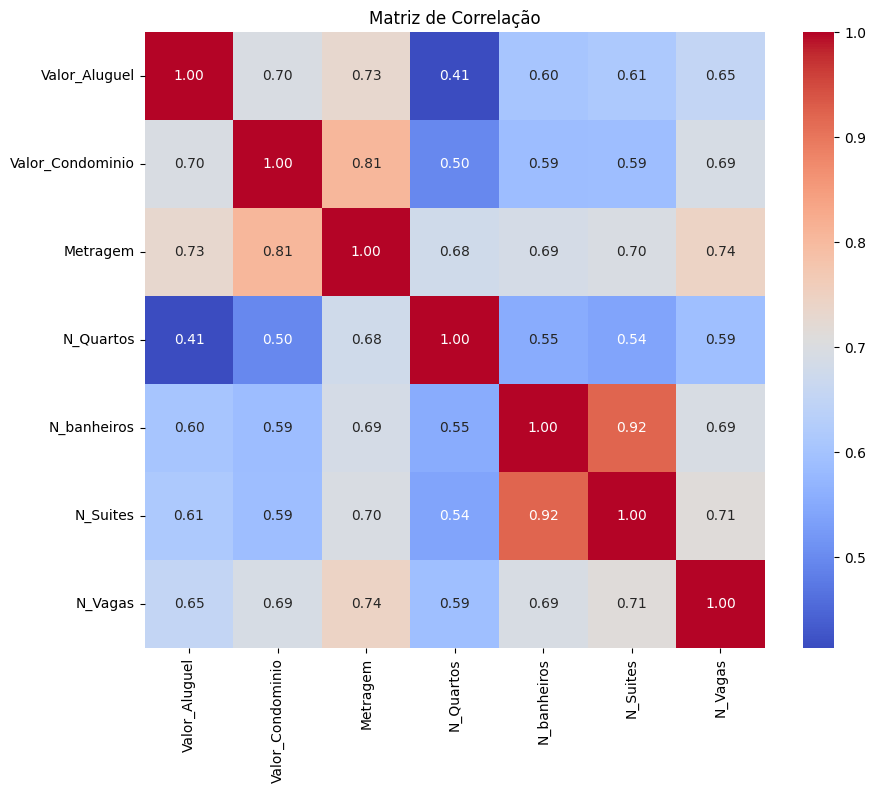

In [20]:
#Seu código aqui
correlation_matrix = df.select_dtypes(include=['number']).corr()
# Plotar o mapa de calor da matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

**Analise da Matriz**
- `N_banheiros e N_Suites` – correlação de 0.92. Extremamente alta correlação. Isso indica que imóveis com mais banheiros geralmente também têm mais suítes.
- `Valor_Condominio e Metragem` – correlação de 0.81, o que sugere que quanto maior a metragem do imóvel, maior tende a ser o valor do condomínio.
- `Metragem e N_Vagas` – correlação de 0.74, revelando que imóveis maiores costumam oferecer mais vagas de garagem.


B) Durante a aula, por nossa base ser pequena e demonstrativa não realizamos a separação de treino e teste, porém para as atividades do dia dia temos que fazer, nesse exercício separe treino e teste.

Lembre-se que primeiro separamos as variaveis dependentes X e depois Y, essa etapa deixarei para vocês abaixo:

In [21]:
X = df.drop('Valor_Aluguel', axis=1) #Separando X - Todas variáveis exceto valor_aluguel
y = df['Valor_Aluguel'] #Separando Y (Apenas variavel valor_aluguel)

Dica: Para separar em treino e teste usamos o train_test_split, como visto nas aulas de pré modelagem.

In [22]:
# Seu código aqui
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [23]:
print("Tamanho de X_train:", X_train.shape)
X_train.to_csv("X_train.csv", index=False)
print("Tamanho de X_test:", X_test.shape)
X_test.to_csv("X_test.csv", index=False)
print("Tamanho de y_train:", y_train.shape)
y_train.to_csv("y_train.csv", index=False)
print("Tamanho de y_test:", y_test.shape)
y_test.to_csv("y_test.csv", index=False)


Tamanho de X_train: (5402, 6)
Tamanho de X_test: (1801, 6)
Tamanho de y_train: (5402,)
Tamanho de y_test: (1801,)


In [24]:
# Atribuindo as variavies de treino e teste em função dos arquivos salvos
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv")
y_test = pd.read_csv("y_test.csv") 


# 3 - Treine um modelo de regressão Linear simples

A) Vamos utilizar apenas X_train e y_train para rodar um modelo de regressão linea simples e para isso usaremos apenas uma váriavel, a váriavel metragem.

In [25]:
Xl = X_train[['Metragem']]  # Variável independente (características)
yl = y_train  # Variável dependente (rótulo)
# se você deu um nome diferente para x train e y train, altere no código.

In [26]:
#Crie seu modelo aqui, usando LinearRegression e as bases de treino
#Criando objeto do tipo LinearRegression
regressao_lienar_valor_aluguel = LinearRegression()

# Treinando o modelo
regressao_lienar_valor_aluguel.fit(Xl, yl)

LinearRegression()

B) Plote o intercept_ e coef_ e monte de forma extensa a equação da reta.

In [27]:
#Seu código Aqui
# Coeficiente linar (intercepto)
intercepto = regressao_lienar_valor_aluguel.intercept_
print(f"Coeficiente linear (intercepto): {intercepto}")

# Coeficiente angualar (coeficiente da variável independente)
coeficiente = regressao_lienar_valor_aluguel.coef_
print(f"Coeficiente angular (coeficiente da variável independente): {coeficiente[0]}")

Coeficiente linear (intercepto): [-103.17820863]
Coeficiente angular (coeficiente da variável independente): [34.70818769]


Nossa equação seria:  Valor_Auguel=34.70(Metragem)+(-103.17)

c) Calcule o R quadrado para o modelo de treinamento. Não esqueça de avaliar e trazer em formato de insight se esse resultado te parece bom ou não.

In [28]:
#Seu código aqui
regressao_lienar_valor_aluguel.score(Xl, yl)

0.5213271756253639

**Avaliando R²**

O coeficiente de determinação R2 apresentado no modelo foi de 0.521, indicando que aproximadamente 52.1% da variação na variável dependente é explicada pelas variáveis independentes ('Metragem') contidas no modelo de regressão. Portanto, o modelo de regressão tem uma capacidade de previsão mediana


D) Plote o gráfico da reta de regressão encontrada e traga insights acerca da dispersão dos pontos e ajuste da reta.

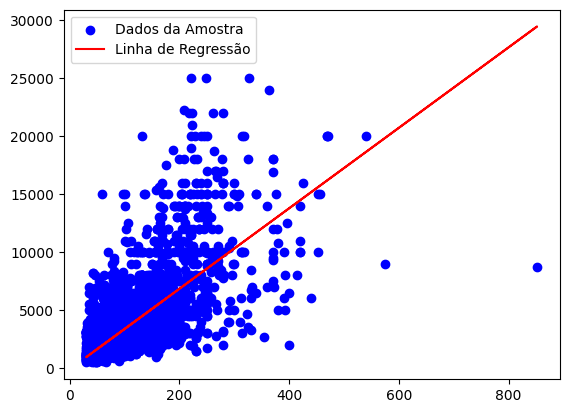

In [29]:
# Seu código aqui
# Plotar os dados originais
plt.scatter(Xl, yl, color='blue', label='Dados da Amostra')

# Plotar a linha de regressão
plt.plot(Xl, regressao_lienar_valor_aluguel.predict(Xl), color='red', label='Linha de Regressão')
plt.legend()
plt.show()

**Analise da reta de regressão**


Como podemos avaliar, os dados não apresentam um ajuste preciso a reta, conseguimos ver uma acúmulo de dados iniciais, porém a dispersão aumenta conforme o aumento da metragem do imovel. Isso justifica o valor do R quadrado encontrado de 50%


E) Para finalizar vamos aplicar o modelo a base de teste. Essa etapa é nova, então agora vocês avaliaram como o modelo treinado se saiu com a base de testes.
Para isso altere no código abaixo o nome do seu modelo de regressão:

In [30]:
Xl_test = X_test[['Metragem']]  # Variável independente (características)
yl_test = y_test  # Variável dependente (rótulo)

In [31]:
# Usando o modelo treinado para fazer previsões sobre os dados de teste
previsoes = regressao_lienar_valor_aluguel.predict(Xl_test)

# Avaliando o desempenho do modelo usando métricas como o R²
r2 = regressao_lienar_valor_aluguel.score(Xl_test, yl_test)

print("Coeficiente de Determinação (R²) nos Dados de Teste:", r2)


Coeficiente de Determinação (R²) nos Dados de Teste: 0.5651600449476675


Se o valor do coeficiente de determinação (R²) para os dados de treinamento for melhor (ou seja, mais próximo de 1) do que o R² para os dados de teste, isso sugere que o modelo está superajustado aos dados de treinamento. Isso significa que o modelo pode estar se ajustando muito bem aos padrões específicos nos dados de treinamento, mas pode não generalizar bem para novos dados que não foram vistos durante o treinamento.

Por outro lado, se o R² para os dados de teste for melhor do que o R² para os dados de treinamento, isso pode ser indicativo de que o modelo está subajustado. Isso significa que o modelo não está se ajustando adequadamente aos padrões nos dados de treinamento e não está capturando a relação entre as variáveis independentes e dependentes de forma eficaz.

Idealmente, gostaríamos que o valor do R² fosse consistente entre os dados de treinamento e teste, indicando que o modelo é capaz de generalizar bem para novos dados. Se houver uma grande diferença entre os valores de R² para os dados de treinamento e teste, isso sugere que o modelo pode precisar de ajustes para melhorar sua capacidade de generalização.

F) Avalie com suas palavras o valor do r quadrado encontrado no treino e no teste.

Escreva sua resposta aqui.

**Avaliação** 

Podemos verificar que o modelo não está sofrendo overfitting, observando uma melhora sutil nos dados de testes (incremento de 4%). Esse valor também reforça a análise anterior sobre a previsibilidade do modelo com a variável independente, onde o modelo não consegue prever com exatidão os dados da nova base.

# 4 - Aplicação do modelo de regressão linear multipla!

A) Vamos refazer os passos anteriores porém para regressão multipla, com todas variáveis dependentes. Comece separando a base treino e teste, dessa vez com todas variáveis para X.

Aqui é só refazer os passos do exercicio 3 porém ao invés de trazer para X apenas metragem, você deve trazer todas colunas (exceto a valor do aluguel).

In [32]:
# Redefinindo variáveis
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv")
y_test = pd.read_csv("y_test.csv") 
#seu código aqui
X = X_train[['Valor_Condominio', 'Metragem', 'N_Quartos', 'N_banheiros','N_Suites', 'N_Vagas']]  # Variável independente
y = y_train  # Variável dependente (rótulo)

B) Faça o modelo de regressão linear multipla aplicado só a base de treino.

In [33]:
#Criando objeto do tipo LinearRegression (Regressão Linear Múltipla)
regressao_multipla_valor_aluguel = LinearRegression()

# Treinando o modelo
regressao_multipla_valor_aluguel.fit(X, y)

LinearRegression()

In [34]:
# Coeficiente linar multiplo (intercepto)
intercepto = regressao_multipla_valor_aluguel.intercept_
print(f"Coeficiente linear (intercepto): {intercepto}")

# Coeficiente angualar Multiplo (coeficiente da variável independente)
coeficiente = regressao_multipla_valor_aluguel.coef_
print(f"Coeficiente angular (coeficiente da variável independente): {coeficiente[0]}")

Coeficiente linear (intercepto): [411.92895077]
Coeficiente angular (coeficiente da variável independente): [   0.77302112   20.72122898 -659.00604215  240.76046013  340.61447028
  522.98401929]


C) Traga o valor do R quadrado e avalie o valor encontrado.

In [ ]:
#seu código aqui
r2 = regressao_multipla_valor_aluguel.score(X, y)

print("Coeficiente de Determinação (R²) nos Dados de Treino da regressão múltipla:", r2)

Coeficiente de Determinação (R²) nos Dados de Treino da regressão multipla: 0.5971610197647366


**Avaliação**

Coeficiente de Determinação (R²) nos Dados de Treino da regressão múltipla se mostraram superiores ao da linear, aproximadamente 60% da variação da variável dependente são explicadas pelas variáveis independentes, pois trouxe mais contexto ao modelo.


D) Para finalizar aplique o modelo a base de teste e traga o r quadrado de teste.
Dica: Você pode usar os códigos do exercício anterior.

In [36]:
#seu código aqui
X = X_test[['Valor_Condominio', 'Metragem', 'N_Quartos', 'N_banheiros','N_Suites', 'N_Vagas']]  # Variável independente
y = y_test  # Variável dependente (rótulo)

# Usando o modelo treinado para fazer previsões sobre os dados de teste
previsoes_m = regressao_multipla_valor_aluguel.predict(X)

# Avaliando o desempenho do modelo usando métricas como o R²
r2m = regressao_multipla_valor_aluguel.score(X, y)

print("Coeficiente de Determinação (R²) nos Dados de Teste:", r2m)

Coeficiente de Determinação (R²) nos Dados de Teste: 0.6327633459161506


E) Compare os r quadrados encontrados pela regressão linear e pela regressão múltipla. Qual modelo te parece melhor? Por qual motivo acredita que isso ocorreu?

**Análise**

Apenas recapitulando os dados de Coeficiente de determinação 
- R² Linear Treino: 0.5213271756253639
- R² Linear Teste: 0.5651600449476675
- R² Múltiplo Treino: 0.5971610197647366
- R² Múltiplo Teste: 0.6327633459161506

Podemos observar uma clara mudança nos R² das regressões, isso se deve ao fato de que estamos adicionando variáveis explicativas ao modelo, ou seja, o contexto dos relacionamento fica mais afinado. Fazendo a regressão apenas com a variável metragem, pode não trazer informações úteis para a análise, adicionando informações como valor do condomínio e  número de quartos, por exemplo, pode-se chegar a um padrão mais assertivo de resultados do valor de aluguel. 
